# Probing Environmental Memory

A quantum system can leave information in its environment and encounter that
information again later. To study this memory, we control one probe qubit,
interrupt its evolution with a measurement and preparation, then ask whether its
future responses still depend on the past. The interruption removes the probe's
direct link to its earlier state while the environment keeps evolving.

We extend the coupling sweep in {doc}`quickstart` to explain the probing
schedule, the response matrix, and its spectrum. We then test memory persistence
under repeated resets and add dephasing in a short process-tensor example. The
examples use the standard YAQS installation and Matplotlib for plotting. Run the
cells in order in a notebook; for a script, use the entry-point guard in
{doc}`simulator_initialization`.

## 1. Define the probe and its environment

Site 0 is our probe qubit. Sites 1 and 2 form an environment that we do not
control or measure directly. All three spins evolve under the transverse-field
Ising Hamiltonian

$$
H=-J(Z_0Z_1+Z_1Z_2)-g(X_0+X_1+X_2).
$$

We fix $g=1$, use $\hbar=1$, and vary $J$. This changes both the
probe–environment coupling and the bond within the environment. At $J=0$ the
probe is isolated, giving a reference with no environmental memory. The default
initial state is $|000\rangle$.

In [1]:
import numpy as np

from mqt.yaqs import AnalogSimParams, Hamiltonian, MemoryCharacterizer

length = 3
couplings = np.linspace(0, 1.5, 13)
params = AnalogSimParams(elapsed_time=0.5, dt=0.5, preset="fast")
characterizer = MemoryCharacterizer(show_progress=False)

The characterizer selects the state representation automatically: vectors for
small systems, and MPS for larger ones. Parallel execution remains enabled. The
documentation suppresses progress bars; omit `show_progress=False` to see them.
Memory characterization currently supports qubit Hamiltonians.

(memory-theory)=

## 2. Choose the probing schedule

Use four interventions separated by evolution intervals of `dt=0.5`. YAQS also
evolves before the first intervention and after the last, giving five intervals
and a total duration of 2.5. With `cut=2`, the second intervention is the
**causal break**: measure a selected outcome and prepare a new probe state.
There is one control before the break and two controls after it.

The default `intervention_style="haar"` draws random single-qubit unitaries for
these controls. Past probes also choose the measurement at the break; future
probes choose its preparation. Keeping these choices separate lets us test
whether past settings affect the future through the environment.

In [2]:
num_interventions = 4
cut = 2
anchor = characterizer.characterize(
    Hamiltonian.ising(length, J=0.0, g=1.0),
    params,
    num_interventions=num_interventions,
    cut=cut,
    preset="quick",
    rng=np.random.default_rng(7),
)

print(anchor.summary())
print("Response matrix shape:", anchor.response_matrix(cut).shape)

cut=2: S_V=-0.0000, modes=1.000
Response matrix shape: (32, 8)


`preset="quick"` selects eight past probes and eight future probes, giving 64
sequences. This preset sets the probe grid; the preset on `AnalogSimParams` sets
numerical accuracy. For Hamiltonian characterization, `dt` sets the interval
between interventions. `elapsed_time` does not set the full probing horizon.
Here it equals one interval so the simulation parameters have a valid time grid.

For each past–future pair, YAQS retains the selected measurement outcome and
records the final probe's $(I,X,Y,Z)$ responses. It multiplies each conditional
response by the joint probability of the retained outcomes. The
**response matrix** $V$ places each history in a column and each future's four
response channels in consecutive rows. Its shape here is $(32,8)$, and its
identity rows contain the outcome probabilities. Keeping these probabilities
avoids treating a rare branch as though it occurred on every run.

## 3. Sweep the coupling with the same probes

Reuse `anchor` as `probe_set` so every coupling uses the same controls,
measurements, and preparations. Otherwise a change in the sampled probes could
be confused with a change in the environment.

In [3]:
memories = [anchor]
for coupling in couplings[1:]:
    memory = characterizer.characterize(
        Hamiltonian.ising(length, J=float(coupling), g=1.0),
        params,
        num_interventions=num_interventions,
        cut=cut,
        probe_set=anchor,
    )
    memories.append(memory)

mode_weights = []
for memory in memories:
    spectrum = memory.singular_values(cut)
    mode_weights.append(spectrum**2 / np.sum(spectrum**2))
entropies = np.array([memory.entropy(cut) for memory in memories])

The singular values $s_k$ describe independent combinations of past settings and
future responses. Their normalized squared weights and entropy are

$$
p_k=\frac{s_k^2}{\sum_j s_j^2},\qquad
S_V=-\sum_k p_k\ln p_k.
$$

`singular_values(cut)` returns the spectrum retained for this entropy, after
removing a numerical tail with relative squared weight at most $10^{-12}$.
`singular_values_full(cut)` returns every compact-SVD value. The entropy uses
natural logarithms, and `memory.modes(cut)` gives the effective mode number
$R=\exp(S_V)$. One retained mode gives $S_V=0$ and $R=1$.

## 4. Read the spectrum and entropy

The spectrum shows how coupling redistributes the response among modes. The
entropy summarizes this spread, allowing us to compare the same probing
experiment across the coupling sweep.

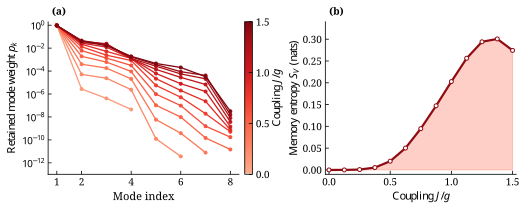

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "svg.fonttype": "none",
})
red_map = LinearSegmentedColormap.from_list("coupling_reds", plt.colormaps["Reds"](np.linspace(0.3, 0.95, 100)))
norm = Normalize(couplings[0], couplings[-1])
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), layout="constrained")
for coupling, weights in zip(couplings, mode_weights, strict=True):
    axes[0].semilogy(np.arange(1, len(weights) + 1), weights, "o-", color=red_map(norm(coupling)), lw=1.3, ms=3)
axes[0].set(xlabel="Mode index", ylabel=r"Retained mode weight $p_k$", ylim=(1e-13, 2), xticks=[1, 2, 4, 6, 8])
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=red_map), ax=axes[0], label=r"Coupling $J/g$", ticks=[0, 0.5, 1, 1.5], fraction=0.05, pad=0.03)
axes[1].fill_between(couplings, entropies, color=red_map(0.35), alpha=0.3)
axes[1].plot(couplings, entropies, "o-", color=red_map(0.95), lw=2.2, ms=4, markerfacecolor="white")
axes[1].set(xlabel=r"Coupling $J/g$", ylabel=r"Memory entropy $S_V$ (nats)", xlim=(-0.03, 1.53), ylim=(-0.01, 0.34), xticks=[0, 0.5, 1, 1.5])
for label, ax in zip(("(a)", "(b)"), axes, strict=True):
    ax.text(0.02, 1.03, label, transform=ax.transAxes, va="bottom", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

**Coupling creates additional response modes, with a peak inside this sweep.**
(a) Darker curves show larger $J$. The uncoupled probe has one retained mode;
coupled dynamics distribute weight among additional modes. (b) The entropy
reaches a maximum near $J/g=1.4$, then decreases. Stronger coupling does not
imply a larger entropy for a fixed schedule and probe grid.

These weights describe the responses accessible through the chosen experiment.
They are not environment populations or Schmidt weights of a mixed state. A
small entropy means that a few modes dominate these responses; it does not prove
that every possible experiment would find the environment memoryless. Changing
the interval, temporal cut, or controls can reveal different memory. The
spectrum alone also does not certify that the memory is quantum rather than
classical.

## Further experiments

(reset-delay)=

### How long does memory persist under resets?

A causal break interrupts the probe once. Repeated resets ask whether the
selected histories remain distinguishable after a longer interruption. With
`delay=N`, YAQS measures the selected history outcome and prepares $|0\rangle$,
inserts $N$ selected-zero measure–prepare resets, then measures zero once more
before the sampled future preparation. The environment evolves between all these
interventions.

In [5]:
hamiltonian = Hamiltonian.ising(length, J=1.0, g=1.0)
delays = np.arange(7)
delay_memories = []
for delay in delays:
    delay_memories.append(characterizer.characterize(
        hamiltonian,
        params,
        num_interventions=num_interventions,
        cut=cut,
        delay=int(delay),
        probe_set=anchor,
    ))
delay_entropies = [memory.entropy(cut) for memory in delay_memories]

Every integer delay, including zero, uses separate boundary interventions. The
sequence has `num_interventions + delay + 1` interventions and one more
evolution interval. Omitting `delay` uses the standard single causal break, so
the ordinary result and the `delay=0` result have different schedules.

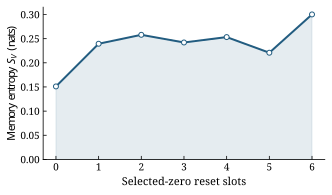

In [6]:
fig, ax = plt.subplots(figsize=(4.5, 2.6), layout="constrained")
ax.plot(delays, delay_entropies, "o-", color="#225c80", lw=2, ms=5, markerfacecolor="white")
ax.fill_between(delays, delay_entropies, color="#225c80", alpha=0.12)
ax.set(xlabel="Selected-zero reset slots", ylabel=r"Memory entropy $S_V$ (nats)", xticks=delays, ylim=(0, None))
ax.spines[["top", "right"]].set_visible(False)
plt.show()

**The conditioned memory varies nonmonotonically with reset delay.** The finite
spin environment continues to evolve and can return information to the probe.
These resets retain particular outcomes rather than averaging over every
measurement result. Their joint probability contributes to $V$, so this is a
conditioned persistence experiment. It does not establish an all-outcome memory
length. Explicit `delay` is supported for Hamiltonian characterization.

### What changes when we add dephasing?

The Hamiltonian `characterize` path does not accept a `NoiseModel`. To include
Markovian noise, first reconstruct a **dense process tensor**, which records the
response to interventions, then pass that tensor to `characterize`. We use two
spins and one causal break to keep this exhaustive reconstruction small. Two
evolution intervals of 0.5 surround the break; the probe and its one-spin
environment retain $J=g=1$.

In [7]:
from mqt.yaqs import NoiseModel

short_hamiltonian = Hamiltonian.ising(2, J=1.0, g=1.0)
noise_params = AnalogSimParams(elapsed_time=0.5, dt=0.025, preset="fast", random_seed=7)
dephasing_rates = [0.0, 1.0, 4.0]
process_tensors = []
noise_memories = []
short_anchor = None
for rate in dephasing_rates:
    noise = None if rate == 0 else NoiseModel([{"name": "pauli_z", "sites": [0], "strength": rate}])
    process = characterizer.build_process_tensor(
        short_hamiltonian,
        noise_params,
        timesteps=[0.5, 0.5],
        return_type="dense",
        noise_model=noise,
        num_trajectories=512,
    )
    memory = characterizer.characterize(
        process,
        cut=1,
        preset="quick",
        probe_set=short_anchor,
        rng=np.random.default_rng(7),
    )
    short_anchor = memory if short_anchor is None else short_anchor
    process_tensors.append(process)
    noise_memories.append(memory)

for rate, memory in zip(dephasing_rates, noise_memories, strict=True):
    print(f"Dephasing rate {rate:g}: {memory.summary()}")

Dephasing rate 0: cut=1: S_V=0.0320, modes=1.033
Dephasing rate 1: cut=1: S_V=0.0035, modes=1.004
Dephasing rate 4: cut=1: S_V=0.0002, modes=1.000


Here `strength=rate` is a Lindblad rate, with jump operator
$L=\sqrt{\gamma}\,Z_0$ and dissipator $\gamma(Z_0\rho Z_0-\rho)$. `timesteps`
defines the two evolution intervals, while `noise_params.dt` sets the
integration step within them. Each of the 16 tomography sequences averages 512
trajectories for nonzero noise. The noiseless reconstruction uses one.

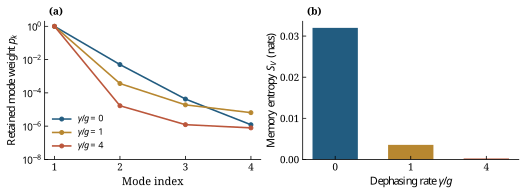

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.6), layout="constrained")
noise_colors = ["#225c80", "#b78730", "#bb563b"]
for rate, memory, color in zip(dephasing_rates, noise_memories, noise_colors, strict=True):
    spectrum = memory.singular_values(1)
    weights = spectrum**2 / np.sum(spectrum**2)
    axes[0].semilogy(np.arange(1, len(weights) + 1), weights, "o-", color=color, ms=4, lw=1.6, label=rf"$\gamma/g={rate:g}$")
axes[0].set(xlabel="Mode index", ylabel=r"Retained mode weight $p_k$", xticks=[1, 2, 3, 4], ylim=(1e-8, 2))
axes[0].legend(frameon=False, fontsize=9, loc="lower left")
axes[1].bar(np.arange(3), [memory.entropy(1) for memory in noise_memories], color=noise_colors, width=0.6)
axes[1].set(xlabel=r"Dephasing rate $\gamma/g$", ylabel=r"Memory entropy $S_V$ (nats)", xticks=np.arange(3), xticklabels=["0", "1", "4"])
for label, ax in zip(("(a)", "(b)"), axes, strict=True):
    ax.text(0.02, 1.03, label, transform=ax.transAxes, va="bottom", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

**Dephasing reduces the weight outside the leading response mode.** (a) The
leading mode gains relative weight as the dephasing rate increases. (b) The
sampled entropy falls. These values describe the two-spin, one-break schedule
and should not be compared directly with the earlier four-intervention sweep.
Small spectral weights can reflect trajectory sampling error; they do not all
establish resolved physical modes. Increase the trajectory count and refine the
integration step before interpreting the smallest weights.

Coupling, resets, and added dephasing answer different questions about the same
physical issue: which traces of earlier probe choices can affect later
responses? Keep the probes and schedule fixed when comparing models, and check
whether the observed spectrum persists as numerical and sampling accuracy
improve.

## Further options

### Probe coverage and representations

`preset="balanced"` uses a $32\times32$ grid and `"accurate"` uses
$128\times128$. Set `n_pasts` and `n_futures` to choose counts explicitly.
Larger grids test more controls; they are not extra trajectories of the same
experiment. Check probe coverage as well as evolution accuracy.

Use `intervention_style="clifford"` for random single-qubit Clifford controls,
or `"measure_prepare"` for rank-one measurement and preparation on every leg.
The default `"haar"` uses random unitaries away from the cut. The choice changes
what memory the experiment can resolve.

Pass `cuts=[...]` or `cuts="all"` to compare temporal cuts. Each cut needs its
own probe geometry, so `probe_set` reuse is restricted to a single cut.
`representation="auto"` on `MemoryCharacterizer` selects vectors up to ten
qubits and MPS above that size. Set `"vector"` or `"mps"` explicitly when
needed. `initial_psi` replaces the default all-zero state for Hamiltonian
characterization. See {class}`~mqt.yaqs.MemoryCharacterizer` for execution and
accuracy options.

### Inspecting response modes

Use `memory.response_matrix(cut)` to inspect $V$. The full compact-SVD factors
from `left_singular_vectors`, `singular_values_full`, and
`right_singular_vectors` satisfy $V=U\operatorname{diag}(s)W^\dagger$. The
columns of $U$ describe future responses, while the columns of $W$ combine
histories. Directions paired with an unresolved tail are not resolved modes, and
vectors inside a degenerate singular subspace are not unique.

### Process tensors and temporal entanglement

`build_process_tensor` defaults to direct MPO construction for noiseless models.
Use `return_type="dense"` for added noise, as above. Both constructions grow
with $16^k$ intervention sequences or histories, so reserve them for short
horizons. Direct construction retains all branches by default; `compress_every`
controls an accumulation batch, not the total number of histories.

A process tensor also provides `compute_temporal_entropy(cut)`, `qmi`, and
`cmi`. These describe the multi-time process, while $S_V$ describes the sampled
probe responses. They are distinct quantities. Reuse the noiseless short-horizon
tensor to compute its temporal operator-Schmidt entropy:

In [9]:
temporal = process_tensors[0].compute_temporal_entropy(1)
print(f"Temporal entropy S_PT: {temporal['entropy']:.4f}")
print(f"Response entropy S_V: {noise_memories[0].entropy(1):.4f}")

Temporal entropy S_PT: 0.0762
Response entropy S_V: 0.0320


Both entropies use natural logarithms. Their values differ because they describe
different objects. The MPO implementations of these diagnostics currently
densify the tensor. Dense storage alone takes 64 MiB at five intervention legs
and 1 GiB at six, before analysis workspace. Operational probing of an MPO
process tensor does not require this conversion.

```{warning}
A finite `max_bond_dim` in direct process-tensor construction enables an
experimental approximation that can violate positivity and causal normalization.
Keep the supported default `None` for scientific references. Noisy tomography
also has finite-sample error; validate reconstructed responses before using them
as a reference.
```

For predicting dynamics under new controls with a trained model, see
{doc}`memory_surrogate`. Surrogate characterization requires `initial_rho`, the
site-0 state after initial evolution and before the first intervention. Use the
reference process tensor's `initial_rho` when the surrogate was trained against
that tensor, and reuse the same `probe_set` for a direct comparison.